## Creating audio model (USE PYTHON VERSION 3.10.20)
### Marissa

### Step 1: Define a function that extracts MFCC features

In [144]:
import librosa
import numpy as np

X, y = [], []

def extract_mfcc(audio_path):
    try:
        audio, sr = librosa.load(audio_path, res_type="kaiser_fast")
        audio = librosa.util.normalize(audio)
    except Exception as e:
        print("Fallback loading for:", audio_path, "| Reason:", e)
        audio, sr = librosa.load(audio_path, sr=None)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    return np.hstack([mfcc_mean, mfcc_std])

### Step 2: Iterate over each audio clip in each genre to extract MFCC features

In [145]:
# Audio files
import pandas as pd
import os

DATASET_PATH = "data/genres_original" # Will need to alter based on your own dataset path.


for genre in os.listdir(DATASET_PATH):
    genre_path = os.path.join(DATASET_PATH, genre)

    if not os.path.isdir(genre_path):
        continue

    for file in os.listdir(genre_path):
        if file.endswith(".wav"):
            file_path = os.path.join(genre_path, file)

            try:
                mfcc = extract_mfcc(file_path)
                X.append(mfcc)
                y.append(genre)
            except Exception as e: # Removes corrupted files (should only be 1)
                print("Skipping:", file_path, e)

print("Loaded", len(X), "files")

/var/folders/k2/xkhh4x_x2999dprlhrz1h_r00000gn/T/ipykernel_27221/1431157125.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_path, res_type="kaiser_fast")
/opt/miniconda3/envs/ml-III-project/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/var/folders/k2/xkhh4x_x2999dprlhrz1h_r00000gn/T/ipykernel_27221/1431157125.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_path, sr=None)


Fallback loading for: data/genres_original/jazz/jazz.00054.wav | Reason: 
Skipping: data/genres_original/jazz/jazz.00054.wav 
Loaded 999 files


### Step 3: Convert to dataframe (rows are audio clips, columns are MFCC features)

In [146]:
X = np.array(X)
y = np.array(y)

df = pd.DataFrame(X)
df["genre"] = y

### Step 4: Check shape of X and y

In [147]:
# X should have shape (999, mfcc_value) and y should have shape (999,)
print(X.shape)
print(y.shape)

(999, 80)
(999,)


### Step 5: One-hot encode genre labels

In [148]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

y_categorical = to_categorical(y_encoded)

### Step 6: Train-test split

In [149]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42,
    stratify=y_encoded
)

### Step 7: Standard Scaling

In [150]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

### Step 8: Building MLP neural network

In [151]:
import tensorflow as tf
import random

seed = 142
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers

model = Sequential()

model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)))

model.add(Dense(y_train.shape[1], activation='softmax'))

/opt/miniconda3/envs/ml-III-project/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Step 9: Compile Model

In [152]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Step 10: Import Early Stopping and Train on Data

In [153]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1268 - loss: 2.4494 - val_accuracy: 0.1437 - val_loss: 2.4294
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1581 - loss: 2.3706 - val_accuracy: 0.1875 - val_loss: 2.3409
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1894 - loss: 2.2808 - val_accuracy: 0.2438 - val_loss: 2.2662
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2332 - loss: 2.2330 - val_accuracy: 0.2625 - val_loss: 2.2017
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2723 - loss: 2.1362 - val_accuracy: 0.3313 - val_loss: 2.1406
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3067 - loss: 2.0729 - val_accuracy: 0.3562 - val_loss: 2.0794
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3224 - loss: 2.0318 - val_accuracy: 0.3750 - val_loss: 2.0197
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3537 - loss: 1.9758 - val_accuracy: 0.4062 - v

### Step 11: Calculate Model Accuracy

In [154]:
loss, acc = model.evaluate(X_val, y_val)

print("Validation Accuracy:", acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6750 - loss: 1.0246  
Validation Accuracy: 0.675000011920929


In [155]:
loss, acc = model.evaluate(X_train, y_train)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8786 - loss: 0.5139


### Step 12: Loss Curve

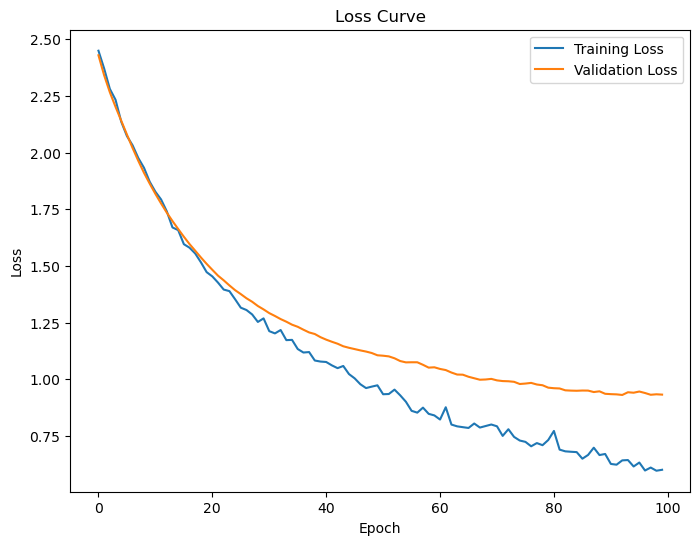

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Test data!

### Testing on 10 new songs per genre (100 songs total) downloaded from Spotify and Youtube.

#### Step 1: Extract MFCC features

In [157]:
X_new, y_new = [], []

DATASET_PATH_NEW = "new_data/genres_new"

for genre in os.listdir(DATASET_PATH_NEW):
    genre_path_new = os.path.join(DATASET_PATH_NEW, genre)

    if not os.path.isdir(genre_path_new):
        continue

    for file in os.listdir(genre_path_new):
        if file.lower().endswith((".mp3", ".m4a", ".wav")):
            file_path_new = os.path.join(genre_path_new, file)

            try:
                mfcc_new = extract_mfcc(file_path_new)
                X_new.append(mfcc_new)
                y_new.append(genre)
            except Exception as e:
                print("Skipping:", file_path_new, e)

print("Loaded", len(X_new), "files")

Fallback loading for: new_data/genres_new/pop/britney-spears-baby-one-more-time-spotisaver_5NARqDYL.mp3 | Reason: No module named 'resampy'

This error is lazily reported, having originally occurred in
  File /opt/miniconda3/envs/ml-III-project/lib/python3.10/site-packages/librosa/core/audio.py, line 33, in <module>

----> resampy = lazy.load("resampy")
Fallback loading for: new_data/genres_new/pop/katseye-gabriela-spotisaver_ZC50Kl1Q.mp3 | Reason: No module named 'resampy'

This error is lazily reported, having originally occurred in
  File /opt/miniconda3/envs/ml-III-project/lib/python3.10/site-packages/librosa/core/audio.py, line 33, in <module>

----> resampy = lazy.load("resampy")
Fallback loading for: new_data/genres_new/pop/ariana-grande-thank-u-next-spotisaver_nUnEoP5B.mp3 | Reason: No module named 'resampy'

This error is lazily reported, having originally occurred in
  File /opt/miniconda3/envs/ml-III-project/lib/python3.10/site-packages/librosa/core/audio.py, line 33, in <mo

/var/folders/k2/xkhh4x_x2999dprlhrz1h_r00000gn/T/ipykernel_27221/1431157125.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_path, res_type="kaiser_fast")
/opt/miniconda3/envs/ml-III-project/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/var/folders/k2/xkhh4x_x2999dprlhrz1h_r00000gn/T/ipykernel_27221/1431157125.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_path, sr=None)


Fallback loading for: new_data/genres_new/pop/pop1.m4a | Reason: No module named 'resampy'

This error is lazily reported, having originally occurred in
  File /opt/miniconda3/envs/ml-III-project/lib/python3.10/site-packages/librosa/core/audio.py, line 33, in <module>

----> resampy = lazy.load("resampy")
Fallback loading for: new_data/genres_new/pop/sabrina-carpenter-please-please-please-spotisaver_Dd1BAh5i.mp3 | Reason: No module named 'resampy'

This error is lazily reported, having originally occurred in
  File /opt/miniconda3/envs/ml-III-project/lib/python3.10/site-packages/librosa/core/audio.py, line 33, in <module>

----> resampy = lazy.load("resampy")
Fallback loading for: new_data/genres_new/pop/pop2.m4a | Reason: No module named 'resampy'

This error is lazily reported, having originally occurred in
  File /opt/miniconda3/envs/ml-III-project/lib/python3.10/site-packages/librosa/core/audio.py, line 33, in <module>

----> resampy = lazy.load("resampy")
Fallback loading for: new

#### Step 2: Create a dataframe

In [158]:
X_test = np.array(X_new)
y_test = np.array(y_new)

df_test = pd.DataFrame(X_test)
df_test["genre"] = y_test

In [159]:
y_encoded_test = encoder.transform(y_test)
y_categorical_test = to_categorical(y_encoded_test)
X_test_scaled = scaler.transform(X_test)

#### Test model

In [160]:
loss_test, acc_test = model.evaluate(X_test_scaled, y_categorical_test)

print("Test Set Accuracy:", acc_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3300 - loss: 2.2296 
Test Set Accuracy: 0.33000001311302185


In [ ]:
from sklearn.metrics import classification_report
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)


y_true = np.argmax(y_categorical_test, axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
results = pd.DataFrame({
    "true": y_true,
    "pred": y_pred
})

genre_acc = results.groupby("true").apply(
    lambda x: (x["true"] == x["pred"]).mean()
)

genre_acc.index = encoder.inverse_transform(genre_acc.index)

print(genre_acc)

blues        0.4
classical    0.6
country      0.2
disco        0.0
hiphop       0.7
jazz         0.2
metal        0.4
pop          0.0
reggae       0.6
rock         0.2
dtype: float64


/var/folders/k2/xkhh4x_x2999dprlhrz1h_r00000gn/T/ipykernel_27221/3709120202.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genre_acc = results.groupby("true").apply(
